In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_regression

In [3]:
X, y = make_regression(n_samples=100, n_features=1, n_informative=1, noise=20, n_targets=1, random_state=41)

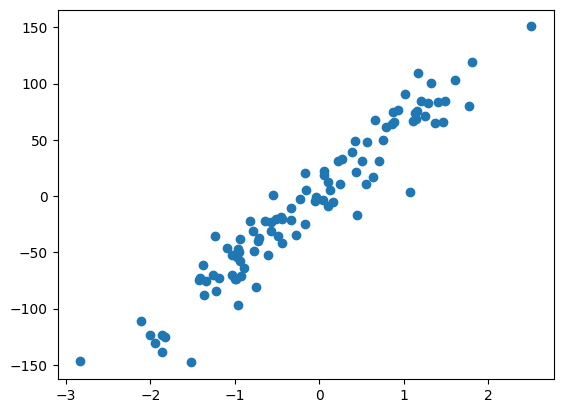

In [4]:
plt.scatter(X, y)

In [5]:
#split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=41)

In [6]:
#train the model
reg = LinearRegression()
reg.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [7]:
print(reg.intercept_)
print(reg.coef_)

0.6785311807319685
[61.23288582]


C:\Users\Lenovo\AppData\Roaming\Python\Python314\site-packages\sklearn\base.py:1365: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
C:\Users\Lenovo\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_coordinate_descent.py:695: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
C:\Users\Lenovo\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.395e+04, tolerance: 3.771e+01
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/

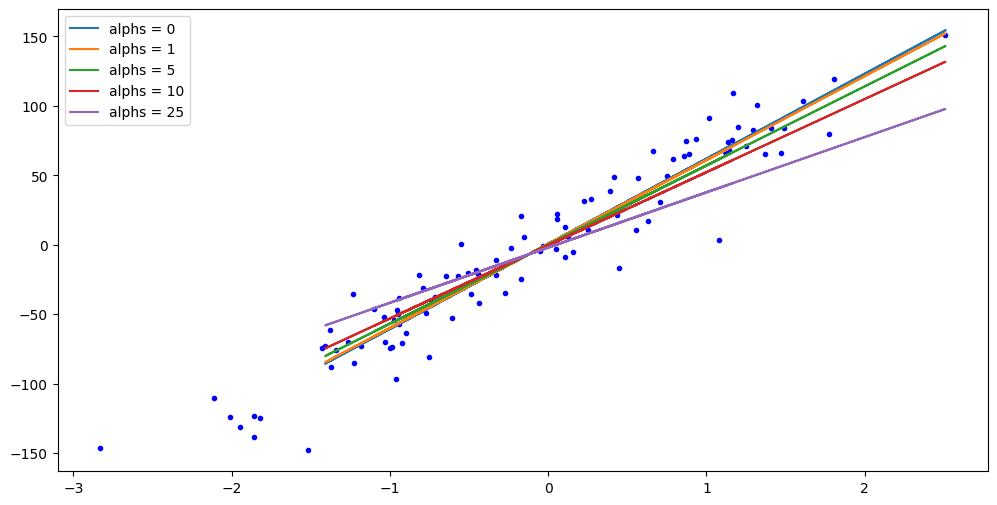

In [10]:
#using lasso regression with different/different value

alphas = [0, 1, 5, 10, 25]
plt.figure(figsize=(12, 6))
plt.plot(X, y, 'b.')
for i in alphas:
    L = Lasso(alpha=i)
    L.fit(X_train, y_train)
    plt.plot(X_test, L.predict(X_test), label = 'alphs = {}'.format(i))
plt.legend()
plt.show()

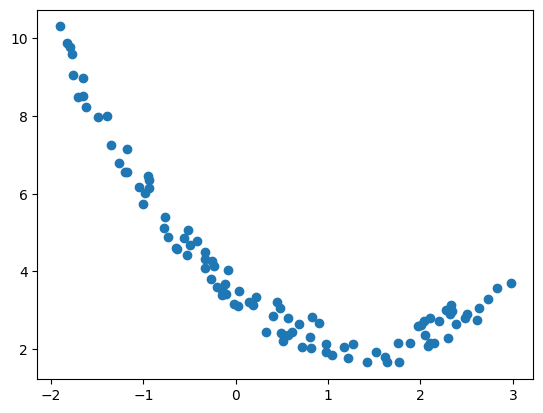

In [40]:
m = 100
x1 = 5*np.random.rand(m, 1) - 2
x2 = 0.7*x1**2 - 2*x1+3+np.random.rand(m, 1)
plt.scatter(x1, x2)
plt.show()

In [44]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge

C:\Users\Lenovo\AppData\Roaming\Python\Python314\site-packages\sklearn\base.py:1365: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
C:\Users\Lenovo\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_coordinate_descent.py:695: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
C:\Users\Lenovo\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.952e+00, tolerance: 4.864e-02
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/

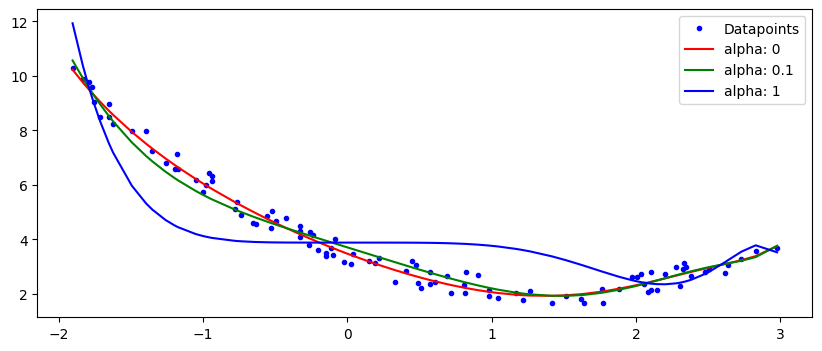

In [75]:
def get_prediction(x1, x2, alpha):
    model = Pipeline([
        ('poly_feats', PolynomialFeatures(degree=15)),
        ('lasso', Lasso(alpha=alpha))
    ])
    model.fit(x1, x2)
    return model.predict(x1)
plt.figure(figsize=(10, 4))
plt.plot(x1, x2, 'b.', label='Datapoints')
alphas = [0, 0.1, 1]
cs = ['r', 'g', 'b']
for alpha, c in zip(alphas, cs):
    preds = get_prediction(x1, x2, alpha)
    #plot
    plt.plot(sorted(x1[:, 0]), preds[np.argsort(x1[:, 0])], c, label = 'alpha: {}'.format(alpha))
plt.legend()
plt.show()